#  Order Quantity Prediction: Exploratory Data Analysis

The objective of this exploratory data analysis is to investigate the characteristics of the predictor variables, assess their relationship with the target variable (quantity_approved), identify potential data quality issues, and prepare the dataset for predictive modeling using both Multiple Linear Regression and Machine Learning algorithms.

Unlike the previous exploratory analysis, which focused on understanding differences between requested and approved quantities, this analysis focuses on identifying the variables that best explain the approval decisions made by the central supply chain.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt
import seaborn as sns 

In [2]:
df=pd.read_csv('../data/dataset_ready_analysis.csv')

In [3]:
df.head()

,product_primary_name,processing_periods_name,facility_type_name,beginning_balance,quantity_received,quantity_dispensed,stock_in_hand,quantity_requested,quantity_approved,total_losses_and_adjustments,amc,pack_size,zone,dispensing_unit,diff
0,PYRA-COMP,2025-05-01,HEALTH CENTER,3510.0,6.0,437.0,1426.0,NaN,0.0,246,151.0,1,DISTRICT28,TABLET,0.0
1,ACT-GC,2025-05-01,HEALTH CENTER,89.0,1.0,57.0,65.0,NaN,620.0,209,20.0,30,DISTRICT28,BLISTER,620.0
2,ACT-AD,2024-02-01,HEALTH CENTER,4125.0,2604.0,1423.0,6554.0,NaN,13.0,-179,1464.0,30,DISTRICT33,BLISTER,13.0
3,ART-SUP,2024-08-01,HEALTH CENTER,20.0,0.0,2.0,185.0,NaN,0.0,-456,0.0,2,DISTRICT36,CAPSULE,0.0
4,RDT,2024-02-01,HEALTH CENTER,2243.0,0.0,535.0,2167.0,NaN,319.0,420,583.0,25,DISTRICT15,PIECE,319.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   product_primary_name          8763 non-null   object 
 1   processing_periods_name       8763 non-null   object 
 2   facility_type_name            8763 non-null   object 
 3   beginning_balance             8763 non-null   float64
 4   quantity_received             8763 non-null   float64
 5   quantity_dispensed            8763 non-null   float64
 6   stock_in_hand                 8763 non-null   float64
 7   quantity_requested            2420 non-null   float64
 8   quantity_approved             8763 non-null   float64
 9   total_losses_and_adjustments  8763 non-null   int64  
 10  amc                           8763 non-null   float64
 11  pack_size                     8763 non-null   int64  
 12  zone                          8763 non-null   object 
 13  dis

In [5]:
df.rename(columns={'diff':'allocation_gap'},inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   product_primary_name          8763 non-null   object 
 1   processing_periods_name       8763 non-null   object 
 2   facility_type_name            8763 non-null   object 
 3   beginning_balance             8763 non-null   float64
 4   quantity_received             8763 non-null   float64
 5   quantity_dispensed            8763 non-null   float64
 6   stock_in_hand                 8763 non-null   float64
 7   quantity_requested            2420 non-null   float64
 8   quantity_approved             8763 non-null   float64
 9   total_losses_and_adjustments  8763 non-null   int64  
 10  amc                           8763 non-null   float64
 11  pack_size                     8763 non-null   int64  
 12  zone                          8763 non-null   object 
 13  dis

As a reminder, here is the data dictionary
* product_primary_name: Product name 
* processing_periods_name: Beginning date of the processing period in format yyy-mm-dd. The reporting period in ou case, is monthly
* facility_type_name: Type of the facility
* beginning_balance: stock of the product at the beginning of the month or reporting period
* quantity_received: Quantity received during the resupply
* quantity_dispensed: Quantity of product used in the facilities
* quantity_approved: Quantity of product approved at the national level  
* total_losses_and_adjustments: Movement of product other than dispensation: losses and adjustments  
* amc: Average Monthly consumption
* pack_size: Number of items (dispense unit) in a pack
* zone: District where the facility is located
* dispensing_unit: Smallest unit give to patient in the prescription
* allocation_gap: Difference of the approved and requested quantity

## 1.Target Variable Exploration
### 1.1. Descriptive statitics

Understand the prediction target before building any model.

In [7]:
target = df["quantity_approved"]
print("Data type:", target.dtype)
print("Number of observations:", len(target))
print("Missing values:", target.isna().sum())

Data type: float64
Number of observations: 8763
Missing values: 0


In [8]:
type(target)

pandas.core.series.Series

The dataset indicates that quantity_approved contains 8,763 non-null observations with no missing values making it suitable for predictive modeling

In [9]:
# Calculate the basic descriptive statistics
target.describe()

count     8763.000000
mean       832.614401
std       2075.873748
min          0.000000
25%          1.000000
50%         42.000000
75%        597.000000
max      52652.000000
Name: quantity_approved, dtype: float64

In [10]:
# Distribution shape
skewness = target.skew()
kurtosis = target.kurt()
print ("Skewness :",skewness)
print ("kurtosis :",kurtosis)

Skewness : 5.668705471636998
kurtosis : 66.2790981221329


In [11]:
std_dev=target.std()
mean= target.mean()
if mean != 0:
    cv = (std_dev / mean) * 100
else:
    cv = np.nan
print('Coefficient of variation: ',cv)

Coefficient of variation:  249.3199426567029


In [12]:
q25,q75=target.quantile([.25,0.75])
IQR=q75-q25
print ('IQR :',IQR)

IQR : 596.0


* The approved quantities range from 0 to 52,652 units, indicating substantial variability in the amounts allocated by the central program.
* The mean approved quantity (832.61) is considerably higher than the median (42.00), suggesting that the distribution is highly right-skewed. This indicates that while most facilities receive relatively small approval quantities, a limited number of observations correspond to very large allocations that increase the overall average. This is further confirmed by the positive skewness of 5.67 ( <-1 or >1), which indicates a pronounced right-skewed distribution. This also confirmed by the kurtosis of 66.28 is substantially higher than 3, indicating an extremely leptokurtic distribution characterized by very heavy tails and a high concentration of extreme values.
* Furthermore, the standard deviation is  2.5 times larger than the mean (CV of 249), highlighting considerable dispersion in the data. Such variability suggests that approval decisions differ considerably across products, facility types, and reporting periods.
* The quartiles show that 25% of observations have approved quantities of one unit or less, 50% are 42 units or less, and 75% are 597 units or less, confirming that most approvals are relatively small compared with a few exceptionally large values.
  
Overall, these descriptive statistics suggest that the target variable is non-normally distributed, with a long right tail and likely contains extreme values. These characteristics will be further examined using graphical methods (histogram, density plot, and boxplot). 
**Although Multiple Linear Regression does not require the target variable itself to be normally distributed, the observed distribution suggests that the regression assumptions, particularly the distribution and homoscedasticity of the residuals, should be carefully evaluated after model fitting. In contrast, tree-based machine learning models such as Decision Trees and Random Forests are generally more robust to highly skewed target distributions and extreme observations**.

### 1.2. Distribution Analysis

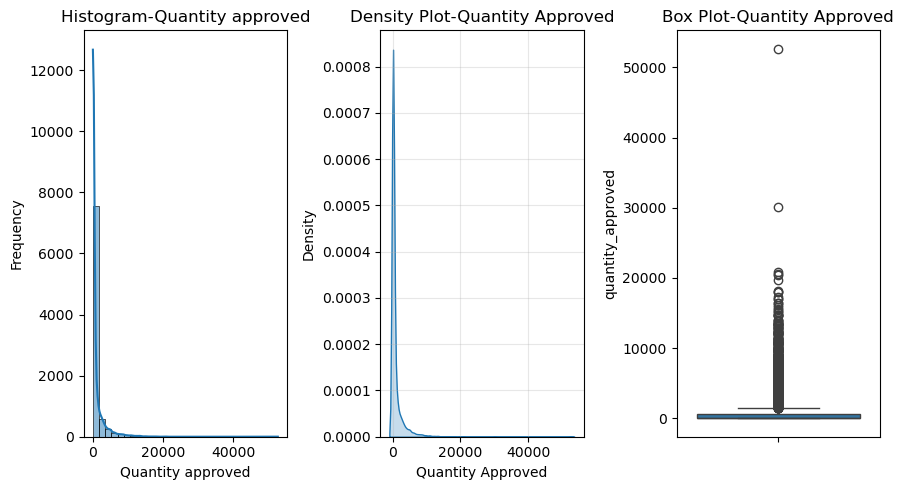

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(9, 5))
# Histogram of Quantity Approved
plt.title('Histogram-Quantity approved');
sns.histplot(
    data=target,
    bins=30,
    kde=True,
    ax=axes[0]
)
axes[0].set_title('Histogram-Quantity approved')
axes[0].set_xlabel('Quantity approved')
axes[0].set_ylabel('Frequency')

# Density Plot-Quantity Approved
sns.kdeplot(
    data=target,
    fill=True,
    bw_adjust=1,
    ax=axes[1]
)
axes[1].set_title('Density Plot-Quantity Approved')
axes[1].set_xlabel('Quantity Approved')
axes[1].set_ylabel('Density')
axes[1].grid(alpha=0.3)

# Density Plot-Quantity Approved
#~#
sns.boxplot(
    data=target,
    ax=axes[2]
)
axes[2].set_title('Box Plot-Quantity Approved')

plt.tight_layout()
plt.show()

The boxplot provides a visual confirmation that the distribution of quantity_approved is highly skewed and characterized by numerous extreme values.
* Most observations are concentrated at relatively small approved quantities, while the frequency decreases rapidly as the approved quantity increases. A small number of observations extend to values exceeding 50,000 units, producing a long right tail.
* The density plot further confirms that the majority of observations are concentrated near zero, with the probability density declining gradually as approved quantities increase. The pronounced peak near the origin and the extended right tail indicate that the distribution departs substantially from normality.
* The box plot reveals a large number of observations beyond the upper whisker, indicating the presence of numerous potential outliers. These observations are not isolated occurrences but are distributed over a wide range of large approved quantities, extending beyond 50,000 units.

The graphical analysis confirms the findings of the descriptive statistics. The target variable exhibits a highly right-skewed distribution, substantial variability, and numerous extreme observations. These graphical characteristics reinforce the conclusion that the response variable is not normally distributed. However, this does not violate the assumptions of Multiple Linear Regression, since those assumptions apply to the model residuals rather than to the response variable itself.

## 2.Predictior variables Exploration
### 2.1. Descriptive statitics

Understand the distribution and quality of every explanatory variable.

In [14]:
# Separate predictors into numerical and categorical variables.
numerical_predictors=df[["quantity_received",'quantity_dispensed','stock_in_hand',
                        'quantity_requested','total_losses_and_adjustments','amc','pack_size']]
categorical_predictors=df[['product_primary_name','processing_periods_name','facility_type_name',
                          'zone','dispensing_unit','quantity_approved']]

In [15]:
numerical_descstats=numerical_predictors.describe()

In [16]:
type(numerical_descstats)

pandas.core.frame.DataFrame

In [17]:
numerical_descstats

,quantity_received,quantity_dispensed,stock_in_hand,quantity_requested,total_losses_and_adjustments,amc,pack_size
count,8763.000000,8763.000000,8763.000000,2420.000000,8763.000000,8763.000000,8763.000000
mean,203.176652,308.405112,1150.421545,745.470661,-5.723268,257.674198,180.924227
std,469.547477,359.092666,1396.491794,487.625668,427.897195,368.191294,362.624183
min,0.000000,0.000000,1.000000,17.000000,-1903.000000,0.000000,1.000000
25%,0.000000,63.000000,207.000000,391.000000,-287.500000,29.000000,5.000000
50%,18.000000,189.000000,669.000000,639.000000,-6.000000,121.000000,30.000000
75%,169.500000,426.000000,1576.000000,1004.250000,280.000000,340.000000,30.000000
max,5542.000000,4337.000000,15912.000000,2950.000000,1634.000000,4327.000000,1000.000000


In [18]:
# This function help to computes additional stats that are not
# provided by the describe() function. These stats are:
# - Coefficient of variation
# - Skewness
# - Kurtosis
# - IQR
def compute_percentiles(df):
    results = []
    for column in df.columns:
        p25,p50,p75, = df[column].quantile([.25,.50,.75])
        iqr = p75 - p25
        mean = df[column].mean()
        median = df[column].median()
        sdt = df[column].std()
        _min = df[column].min()
        _max = np.max(df[column])
        if mean != 0:
            cv = (sdt / mean) * 100
        else:
            cv = np.nan

        skewness = df[column].skew()
        kurtosis = df[column].kurt()
        results.append(
            {
            'Variables': column,
            'Mean': mean,
            'Median': median,
            'SD': sdt,
            'Min': _min,
            'Q1': p25,
            'Q1': p25,            
            'Q2': p50,
            'Q3': p75,
            'Max': _max,
            'iqr': iqr,
            'Skewness': skewness,
            'Kurtosis': kurtosis,
           
            }
        )
    return results

In [19]:
stats_result=compute_percentiles(numerical_predictors)
df_stats_results = pd.DataFrame(stats_result)
df_stats_results

,Variables,Mean,Median,SD,Min,Q1,Q2,Q3,Max,iqr,Skewness,Kurtosis
0,quantity_received,203.176652,18.0,469.547477,0.0,0.0,18.0,169.50,5542.0,169.50,4.271223,24.051412
1,quantity_dispensed,308.405112,189.0,359.092666,0.0,63.0,189.0,426.00,4337.0,363.00,2.457040,9.615333
2,stock_in_hand,1150.421545,669.0,1396.491794,1.0,207.0,669.0,1576.00,15912.0,1369.00,2.560276,10.262147
3,quantity_requested,745.470661,639.0,487.625668,17.0,391.0,639.0,1004.25,2950.0,613.25,1.205190,1.710012
4,total_losses_and_adjustments,-5.723268,-6.0,427.897195,-1903.0,-287.5,-6.0,280.00,1634.0,567.50,0.008435,0.075530
5,amc,257.674198,121.0,368.191294,0.0,29.0,121.0,340.00,4327.0,311.00,3.185259,15.792166
6,pack_size,180.924227,30.0,362.624183,1.0,5.0,30.0,30.00,1000.0,25.00,1.812075,1.295790


**1. Quantity Received**
The mean (203.18) is considerably higher than the median (18), while the high positive skewness (4.27) and kurtosis (24.05) indicate a highly right-skewed distribution with numerous extreme values. 

**2. Quantity Dispensed**
The mean (308.41) exceeds the median (189), indicating a moderately right-skewed distribution, which is confirmed by the skewness (2.46) and leptokurtic kurtosis (9.62). The relatively high variability suggests substantial differences in commodity consumption across facilities.

**3. Stock in Hand**
The mean (1,150.42) is notably higher than the median (669), while the skewness (2.56) and kurtosis (10.26) indicate a strongly right-skewed distribution with heavy tails

**4. Quantity Requested**
The mean (745.47) is moderately higher than the median (639), and the skewness (1.21) indicates a moderate positive skew with relatively mild kurtosis (1.71). Compared with the other logistics variables, its distribution is closer to symmetry and may be more suitable for linear modeling.

**5. Total Losses and Adjustments**
The mean (−5.72) and median (−6) are nearly identical, while the skewness (0.01) and kurtosis (0.08) indicate an approximately symmetric distribution with no evidence of substantial tail heaviness. Among all numerical predictors, this variable most closely resembles a normal distribution

**5. Average Monthly Consumption (AMC)**
The mean (257.67) is substantially higher than the median (121), and the skewness (3.19) together with the kurtosis (15.79) indicate a highly right-skewed distribution with numerous extreme values.

Overall, most numerical predictor variables exhibit positive skewness, heavy-tailed distributions, and extreme values, with the exception of total_losses_and_adjustments, which is approximately symmetric. These characteristics suggest that several predictors deviate from normality and may contain influential observations. While the distribution of predictor variables does not constitute a formal assumption of Multiple Linear Regression, these characteristics may influence the linearity, homoscedasticity, and distribution of the model residuals. Consequently, graphical analyses and regression diagnostics will be conducted after model fitting.

### 2.2. Visualization - Distribution Analysis

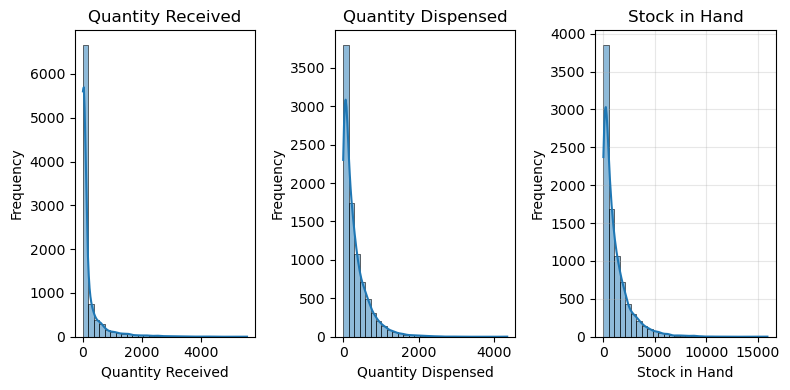

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(8, 4))
# Histogram of Quantity Requested
sns.histplot(
    data=numerical_predictors,
    x='quantity_received',
    bins=30,
    kde=True,
    ax=axes[0]
)
axes[0].set_title('Quantity Received')
axes[0].set_xlabel('Quantity Received')
axes[0].set_ylabel('Frequency')
###
# Histogram of Quantity Approved
sns.histplot(
    data=numerical_predictors,
    x='quantity_dispensed',
    bins=30,
    kde=True,
    ax=axes[1]
)

axes[1].set_title('Quantity Dispensed')
axes[1].set_xlabel('Quantity Dispensed')
axes[1].set_ylabel('Frequency')
###
# Histogram of stock in hand
sns.histplot(
    data=numerical_predictors,
    x='stock_in_hand',
    bins=30,
    kde=True,
    ax=axes[2]
)
axes[2].set_title('Stock in Hand')
axes[2].set_xlabel('Stock in Hand')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

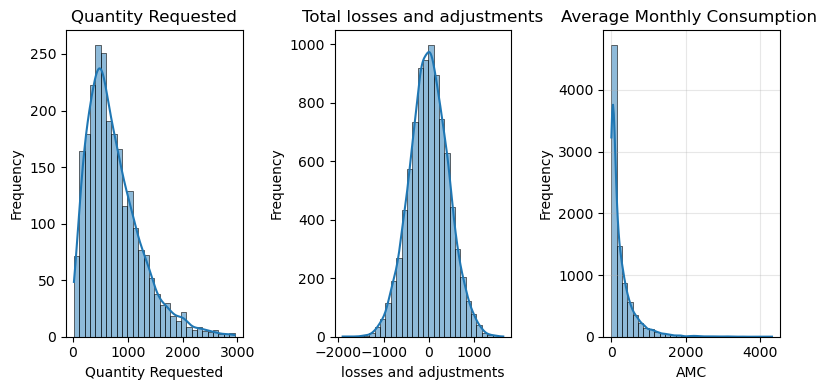

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(8, 4))
# Histogram of Quantity Requested
sns.histplot(
    data=numerical_predictors,
    x='quantity_requested',
    bins=30,
    kde=True,
    ax=axes[0]
)
axes[0].set_title('Quantity Requested')
axes[0].set_xlabel('Quantity Requested')
axes[0].set_ylabel('Frequency')
###
# Histogram of Quantity Approved
sns.histplot(
    data=numerical_predictors,
    x='total_losses_and_adjustments',
    bins=30,
    kde=True,
    ax=axes[1]
)

axes[1].set_title('Total losses and adjustments')
axes[1].set_xlabel('losses and adjustments')
axes[1].set_ylabel('Frequency')
###
# Histogram of stock in hand
sns.histplot(
    data=numerical_predictors,
    x='amc',
    bins=30,
    kde=True,
    ax=axes[2]
)
axes[2].set_title('Average Monthly Consumption ')
axes[2].set_xlabel('AMC')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

* The variables quantity_received, quantity_dispensed, stock_in_hand, and average monthly consumption (AMC) exhibit pronounced right-skewed distributions, with most observations concentrated at relatively small values and progressively fewer observations occurring at higher values
* In contrast, quantity_requested displays a moderately right-skewed distribution, with observations more evenly distributed around the center and fewer extreme values than the other logistics variables. This suggests a distribution that is closer to symmetry and may therefore be more suitable for linear modeling
* The histogram of total_losses_and_adjustments is approximately bell-shaped and symmetric, with values distributed around zero and no evidence of substantial skewness. This observation is consistent with its near-zero skewness and low kurtosis, indicating that this predictor closely resembles a normal distribution

Overall, the graphical analysis confirms the descriptive statistics by demonstrating that most numerical predictors deviate from normality to varying degrees.
* From a predictive modeling perspective, the observed distributions do not violate the assumptions of Multiple Linear Regression, since regression does not require predictor variables to be normally distributed. Nevertheless, highly skewed predictors and influential observations may contribute to non-linearity, heteroscedasticity, or influential residuals, which will be assessed through regression diagnostics after fitting the model.
* Conversely, Decision Trees and Random Forests are generally insensitive to skewed predictor distributions and extreme observations because they partition the feature space using recursive decision rules rather than relying on distributional assumptions.

### 2.3. Categorical predictor analysis

This section explores the categorical predictors in relation to the target variable, quantity_approved.

The analysis will compute, for each categorical variable:

* number of categories;
* frequency of each category;
* percentage of observations;
* median approved quantity by category. Because quantity_approved is highly right-skewed, the mean will be strongly influenced by exceptionally large approvals. For that reason, We opted for the median approved_quantity alongside the mean.

In [22]:
def categorical_eda_modeling(
    dataframe,
    categorical_column,
    target_column="quantity_approved",
    include_missing=True
):
    """
    Categorical EDA designed for predictive modeling.
    """

    required_columns = [categorical_column, target_column]

    missing_columns = [
        column for column in required_columns
        if column not in dataframe.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Columns not found in dataframe: {missing_columns}"
        )

    data = dataframe[required_columns].copy()

    data[target_column] = pd.to_numeric(
        data[target_column],
        errors="coerce"
    )

    if include_missing:
         data[categorical_column] = (
            data[categorical_column]
            .astype("object")
            .fillna("Missing")
        )
    else:
        data = data.dropna(subset=[categorical_column])

    number_of_categories = data[categorical_column].nunique()

    summary = (
        data.groupby(
            categorical_column,
            dropna=False
        )
        .agg(
            frequency=(categorical_column, "size"),
            target_count=(target_column, "count"),
            average_quantity_approved=(target_column, "mean"),
            median_quantity_approved=(target_column, "median"),
            std_quantity_approved=(target_column, "std"),
            minimum_quantity_approved=(target_column, "min"),
            maximum_quantity_approved=(target_column, "max")
        )
        .reset_index()
    )

    summary["percentage"] = (
        summary["frequency"] / len(data) * 100
    )

    summary["rare_category"] = (
        summary["percentage"] < 1
    )

    summary = summary[
        [
            categorical_column,
            "frequency",
            "percentage",
            "rare_category",
            "target_count",
            "average_quantity_approved",
            "median_quantity_approved",
            "std_quantity_approved",
            "minimum_quantity_approved",
            "maximum_quantity_approved"
        ]
    ]

    numeric_columns = [
        "percentage",
        "average_quantity_approved",
        "median_quantity_approved",
        "std_quantity_approved",
        "minimum_quantity_approved",
        "maximum_quantity_approved"
    ]

    summary[numeric_columns] = summary[numeric_columns].round(2)

    summary = summary.sort_values(
        by="frequency",
        ascending=False
    ).reset_index(drop=True)

    return summary, number_of_categories 

In [23]:
facility_summary, facility_category_count = categorical_eda_modeling(
    dataframe=categorical_predictors,
    categorical_column="facility_type_name",
    target_column="quantity_approved"
)

print("Number of categories:", facility_category_count)

facility_summary

Number of categories: 4


,facility_type_name,frequency,percentage,rare_category,target_count,average_quantity_approved,median_quantity_approved,std_quantity_approved,minimum_quantity_approved,maximum_quantity_approved
0,HEALTH CENTER,8091,92.33,False,8091,832.39,43.0,2060.30,0.0,52652.0
1,DISTRICT HOSPITAL,512,5.84,False,512,875.93,28.0,2408.74,0.0,30146.0
2,REGIONAL HOSPITAL,114,1.30,False,114,842.81,24.0,1904.41,0.0,14055.0
3,NATIONAL HOSPITAL,46,0.52,True,46,365.09,5.0,831.77,0.0,4233.0


In [24]:
categorical_column="facility_type_name"
target_column="quantity_approved"
required_columns = [categorical_column, target_column]
data = categorical_predictors[required_columns].copy()
data = data.dropna(subset=[categorical_column])
data

,facility_type_name,quantity_approved
0,HEALTH CENTER,0.0
1,HEALTH CENTER,620.0
2,HEALTH CENTER,13.0
3,HEALTH CENTER,0.0
4,HEALTH CENTER,319.0
...,...,...
8758,HEALTH CENTER,0.0
8759,HEALTH CENTER,5.0
8760,HEALTH CENTER,86.0
8761,HEALTH CENTER,0.0


In [25]:
modeling_categorical_results = {}
for column in categorical_predictors.columns:
    if column=='quantity_approved':
        continue
    else:
        #print('----------',column,'----------------')
        summary, number_of_categories = categorical_eda_modeling(
        dataframe=categorical_predictors,
        categorical_column=column,
        target_column="quantity_approved")
        modeling_categorical_results[column] = summary
        #print(summary)
#modeling_categorical_results
#modeling_categorical_results
#index = 1
for categorical_results in modeling_categorical_results:
    #print(modeling_categorical_results[categorical_results])
    print('-------',categorical_results,'------------')
    #modeling_categorical_results[categorical_results]
    #print(type (modeling_categorical_results[categorical_results]))
    ##df = pd.DataFrame(categorical_results);
    #print ("-----",index,"----")
    #index = index + 1

------- product_primary_name ------------
------- processing_periods_name ------------
------- facility_type_name ------------
------- zone ------------
------- dispensing_unit ------------


In [26]:
modeling_categorical_results["product_primary_name" ]

,product_primary_name,frequency,percentage,rare_category,target_count,average_quantity_approved,median_quantity_approved,std_quantity_approved,minimum_quantity_approved,maximum_quantity_approved
0,ART-SUP,781,8.91,False,781,734.23,33.0,1718.56,0.0,14710.0
1,RDT,770,8.79,False,770,761.68,41.5,1778.80,0.0,18123.0
2,ACT-INF,748,8.54,False,748,811.19,68.0,1852.47,0.0,20456.0
3,ART-INJ,747,8.52,False,747,822.92,35.0,2293.17,0.0,30146.0
4,ACT-GC,745,8.50,False,745,941.56,56.0,2064.08,0.0,20596.0
5,ITN,744,8.49,False,744,887.18,46.5,2097.48,0.0,19766.0
6,ACT-AD,730,8.33,False,730,894.97,42.5,2241.25,0.0,17934.0
7,QUIN,728,8.31,False,728,662.33,35.5,1616.13,0.0,16189.0
8,ACT-SC,722,8.24,False,722,802.14,38.0,1951.84,0.0,16464.0
9,SP,706,8.06,False,706,845.41,29.5,2097.52,0.0,17259.0


#### product_primary_name

* The variable contains 12 product categories, with frequencies ranging from 648 observations (7.39%) for PYRA-COMP to 781 observations (8.91%) for ART-SUP.

* All categories represent more than 7% of the dataset, and none meets the defined rare-category threshold of less than 1%. Each category also contains more than 600 observations, which is sufficient for model training and validation.

* The difference between the largest category, ART-SUP at 8.91%, and the smallest, PYRA-COMP at 7.39%, is only 1.52 percentage points. The largest category is approximately 1.2 times the size of the smallest, indicating a well-balanced distribution.

* Average approved quantities range from 662.33 units for QUIN to 956.53 units for PYRA-SAC. However, the category means are substantially higher than their medians, which range from 29.5 to 68 units. This indicates that the averages are strongly influenced by exceptionally large approvals within each product category.

* No category is rare or underrepresented; therefore, category grouping is not required before modeling.

The 12 categories should therefore be retained separately and encoded using one-hot encoding for Multiple Linear Regression, Decision Trees, and Random Forests.

In [27]:
modeling_categorical_results["processing_periods_name"]

,processing_periods_name,frequency,percentage,rare_category,target_count,average_quantity_approved,median_quantity_approved,std_quantity_approved,minimum_quantity_approved,maximum_quantity_approved
0,2025-08-01,1138,12.99,False,1138,777.97,26.5,1945.26,0.0,14766.0
1,2025-02-01,1129,12.88,False,1129,966.13,57.0,2519.57,0.0,52652.0
2,2025-05-01,1107,12.63,False,1107,868.10,48.0,2147.37,0.0,19766.0
3,2024-11-01,1106,12.62,False,1106,766.23,44.0,2044.30,0.0,30146.0
4,2025-11-01,1099,12.54,False,1099,856.74,40.0,2078.36,0.0,18123.0
5,2024-05-01,1081,12.34,False,1081,793.32,42.0,1848.04,0.0,17939.0
6,2024-08-01,1065,12.15,False,1065,877.13,34.0,2196.58,0.0,20596.0
7,2024-02-01,1038,11.85,False,1038,749.90,45.0,1692.35,0.0,15866.0


#### processing_periods_name

* The variable contains 8 reporting periods, with frequencies ranging from 1,038 observations (11.85%) for 2024-02 to 1,138 observations (12.99%) for 2025-08.
* All reporting periods represent more than 11% of the dataset, and none meets the defined rare-category threshold of less than 1%. Each reporting period also contains more than 1,000 observations, which is sufficient for model training and validation.
* The difference between the largest reporting period, 2025-08 (12.99%), and the smallest, 2024-02 (11.85%), is only 1.14 percentage points. The largest reporting period is approximately 1.1 times the size of the smallest, indicating a well-balanced temporal distribution.
* Average approved quantities range from 749.90 units for 2024-02 to 966.13 units for 2025-02. However, the period means are substantially higher than their medians, which range from 26.5 to 57 units. This indicates that the averages are strongly influenced by exceptionally large approval quantities within each reporting period.
* No reporting period is rare or underrepresented; therefore, category grouping is not required before modeling.

Rather than using the complete reporting period (year-month-day) as a categorical predictor, the reporting month (February, May, August, and November) will be extracted and used as the temporal feature. This representation captures the quarterly ordering cycle while allowing the predictive models to learn seasonal ordering patterns and generalize to future reporting periods. The derived reporting month will therefore be encoded using one-hot encoding for Multiple Linear Regression, Decision Trees, and Random Forests.

In [28]:
modeling_categorical_results["facility_type_name"]

,facility_type_name,frequency,percentage,rare_category,target_count,average_quantity_approved,median_quantity_approved,std_quantity_approved,minimum_quantity_approved,maximum_quantity_approved
0,HEALTH CENTER,8091,92.33,False,8091,832.39,43.0,2060.30,0.0,52652.0
1,DISTRICT HOSPITAL,512,5.84,False,512,875.93,28.0,2408.74,0.0,30146.0
2,REGIONAL HOSPITAL,114,1.30,False,114,842.81,24.0,1904.41,0.0,14055.0
3,NATIONAL HOSPITAL,46,0.52,True,46,365.09,5.0,831.77,0.0,4233.0


#### facility_type_name

* The variable contains 4 facility types, with frequencies ranging from 46 observations (0.52%) for National Hospitals to 8,091 observations (92.33%) for Health Centers.
* Three facility types (Health Centers, District Hospitals, and Regional Hospitals) exceed the 1% rare-category threshold and contain sufficient observations for model training. However, National Hospitals represent only 0.52% of the dataset with 46 observations and are therefore classified as a rare category.
* The distribution of observations across facility types is highly imbalanced. Health Centers account for more than 92% of all observations, whereas District Hospitals, Regional Hospitals, and National Hospitals together represent less than 8% of the dataset. This imbalance reflects the structure of the health system, where Health Centers constitute the majority of service delivery points.
* Average approved quantities range from 365.09 units for National Hospitals to 875.93 units for District Hospitals. However, the category means are substantially higher than their medians, which range from 5 to 43 units, indicating that the averages are strongly influenced by exceptionally large approval quantities within each facility type.
* Because National Hospitals are underrepresented, they may not provide sufficient information for the models to learn reliable facility-specific patterns. Consequently, National Hospitals will be grouped with Regional and District Hospitals under a single Hospital category, while Health Centers  will be retained as separate categories. This grouping increases the number of observations in the hospital category while preserving the operational distinction between primary health facilities and hospitals.
  
The resulting facility-type categories will therefore be encoded using one-hot encoding for Multiple Linear Regression, Decision Trees, and Random Forests.

In [29]:
modeling_categorical_results["zone"]

,zone,frequency,percentage,rare_category,target_count,average_quantity_approved,median_quantity_approved,std_quantity_approved,minimum_quantity_approved,maximum_quantity_approved
0,DISTRICT31,469,5.35,False,469,800.52,24.0,1951.97,0.0,17259.0
1,DISTRICT29,416,4.75,False,416,774.37,39.0,1692.99,0.0,13378.0
2,DISTRICT33,405,4.62,False,405,1018.76,39.0,2418.05,0.0,20596.0
3,DISTRICT28,395,4.51,False,395,840.71,38.0,2313.93,0.0,30146.0
4,DISTRICT20,364,4.15,False,364,748.51,35.0,1962.16,0.0,15128.0
5,DISTRICT32,362,4.13,False,362,748.64,39.5,1756.11,0.0,14766.0
6,DISTRICT13,353,4.03,False,353,661.58,28.0,1634.08,0.0,12926.0
7,DISTRICT9,349,3.98,False,349,665.57,39.0,1460.03,0.0,9612.0
8,DISTRICT23,343,3.91,False,343,1075.50,32.0,3646.26,0.0,52652.0
9,DISTRICT25,320,3.65,False,320,848.46,33.0,1958.91,0.0,13521.0


#### zone

* The variable contains 37 districts (zones), with frequencies ranging from 79 observations (0.90%) for DISTRICT27 to 469 observations (5.35%) for DISTRICT31.
* Almost all districts exceed the defined rare-category threshold of 1% and contain sufficient observations for model training. However, DISTRICT27 represents only 0.90% of the dataset with 79 observations and is therefore classified as a rare category.
* The distribution of observations across districts is moderately balanced. The largest district (DISTRICT31, 5.35%) contains approximately six times more observations than the smallest district (DISTRICT27, 0.90%). Nevertheless, the majority of districts contribute between 1% and 5% of the dataset, indicating that no single district dominates significantly the data.
* Average approved quantities range from 534.23 units  to 1,134.28 units. However, the district means are substantially higher than their corresponding medians, which range from 23 to 97 units, indicating that average approved quantities are strongly influenced by exceptionally large approvals within each district.
* Although DISTRICT27 is identified as a rare category, the remaining districts are adequately represented. Therefore, grouping districts solely to address category imbalance is not necessary.
* Because the variable contains 37 categories, directly applying one-hot encoding would substantially increase the number of model parameters while providing limited interpretability. Consequently, the zone variable will be transformed into a higher-level geographical feature which is the zone_type: Urban and Rural before modeling.

#### Dispensing unit
I actually would not include dispensing_unit as a predictor in our predictive model since it would not bring much information to the EDA. It is a physical characteristic of the product, not a factor that drives demand or central allocation decisions.

### Visualization

In [33]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import colors
# Creating a Green -> Yellow -> Red Gradient
cmap = LinearSegmentedColormap.from_list(
    "custom_gradient",
    ["green", "yellow", "red"]
)

In [34]:
categorical_predictors['product_primary_name'].unique()

array(['PYRA-COMP', 'ACT-GC', 'ACT-AD', 'ART-SUP', 'RDT', 'ACT-SC',
       'ACT-INF', 'ART-INJ', 'ITN', 'QUIN', 'SP', 'PYRA-SAC'],
      dtype=object)

In [35]:
product_order = ['ACT-INF', 'ACT-SC', 'ACT-GC', 'ACT-AD','ART-SUP','ART-INJ','QUIN','SP','PYRA-SAC','PYRA-COMP','RDT','ITN']

In [36]:
categorical_predictors['product_primary_name']

0       PYRA-COMP
1          ACT-GC
2          ACT-AD
3         ART-SUP
4             RDT
          ...    
8758    PYRA-COMP
8759       ACT-AD
8760      ACT-INF
8761      ART-SUP
8762       ACT-SC
Name: product_primary_name, Length: 8763, dtype: object

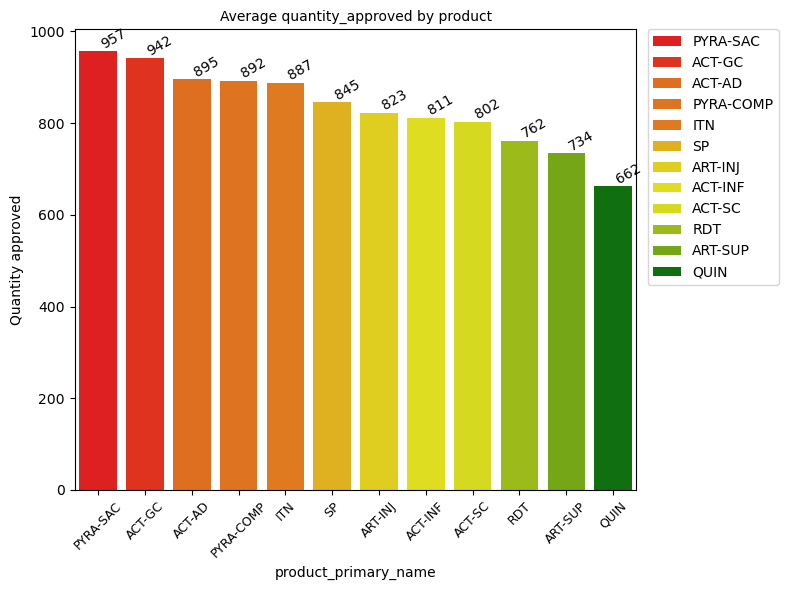

In [37]:
plt.figure(figsize=(8,6))
# Create bar plot of total quantities approved per products
qty_by_product= (
    #categorical_predictors[categorical_predictors['product_primary_name'].isin(['ACT-INF', 'ACT-SC', 'ACT-GC', 'ACT-AD'])].groupby('product_primary_name')['quantity_approved']
    categorical_predictors.groupby('product_primary_name')['quantity_approved']
      .mean()
      .sort_values(ascending=False)
)
#qty_by_product=qty_by_product.reindex(index=product_order)
# Normalisation des valeurs
norm = colors.Normalize(
    vmin=qty_by_product.min(),
    vmax=qty_by_product.max()
)
# Assigning a color to each bar
bar_colors = [cmap(norm(value)) for value in qty_by_product.values]
ax=sns.barplot(x=qty_by_product.index, y=qty_by_product.values,palette=bar_colors, hue=qty_by_product.index,
                 legend=True )
#ax.set_xticklabels(product_order)
# Add labels on bars
for container in ax.containers:
    labels=ax.bar_label(container, fmt='{:,.0f}')
    for label in labels:
        label.set_rotation(30)
        label.set_horizontalalignment('left')
        label.set_verticalalignment('bottom')
ax.set_ylabel('Quantity approved')
ax.tick_params(axis='x', labelrotation=45, labelsize=9)
ax.set_title('Average quantity_approved by product', fontsize=10);
#plt.xticks(rotation=45, ha='right')
ax.legend(title='',loc="upper left",
    bbox_to_anchor=(1.02, 1),   # Outside the plot on the right
    borderaxespad=0)
plt.tight_layout()
plt.show()

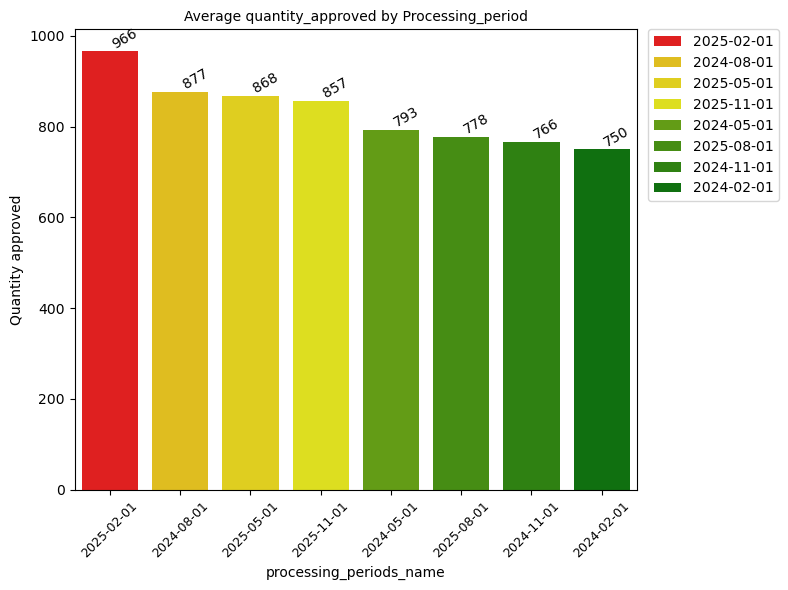

In [38]:
plt.figure(figsize=(8,6))
# Create bar plot of total quantities approved per products
qty_by_period= (
    #categorical_predictors[categorical_predictors['product_primary_name'].isin(['ACT-INF', 'ACT-SC', 'ACT-GC', 'ACT-AD'])].groupby('product_primary_name')['quantity_approved']
    categorical_predictors.groupby('processing_periods_name')['quantity_approved']
      .mean()
      .sort_values(ascending=False)
)
#qty_by_product=qty_by_product.reindex(index=product_order)
# Normalisation des valeurs
norm = colors.Normalize(
    vmin=qty_by_period.min(),
    vmax=qty_by_period.max()
)
# Assigning a color to each bar
bar_colors = [cmap(norm(value)) for value in qty_by_period.values]
ax=sns.barplot(x=qty_by_period.index, y=qty_by_period.values,palette=bar_colors, hue=qty_by_period.index,
                 legend=True )
#ax.set_xticklabels(product_order)
# Add labels on bars
for container in ax.containers:
    labels=ax.bar_label(container, fmt='{:,.0f}')
    for label in labels:
        label.set_rotation(30)
        label.set_horizontalalignment('left')
        label.set_verticalalignment('bottom')
ax.set_ylabel('Quantity approved')
ax.tick_params(axis='x', labelrotation=45, labelsize=9)
ax.set_title('Average quantity_approved by Processing_period', fontsize=10);
#plt.xticks(rotation=45, ha='right')
ax.legend(title='',loc="upper left",
    bbox_to_anchor=(1.02, 1),   # Outside the plot on the right
    borderaxespad=0)
plt.tight_layout()
plt.show()

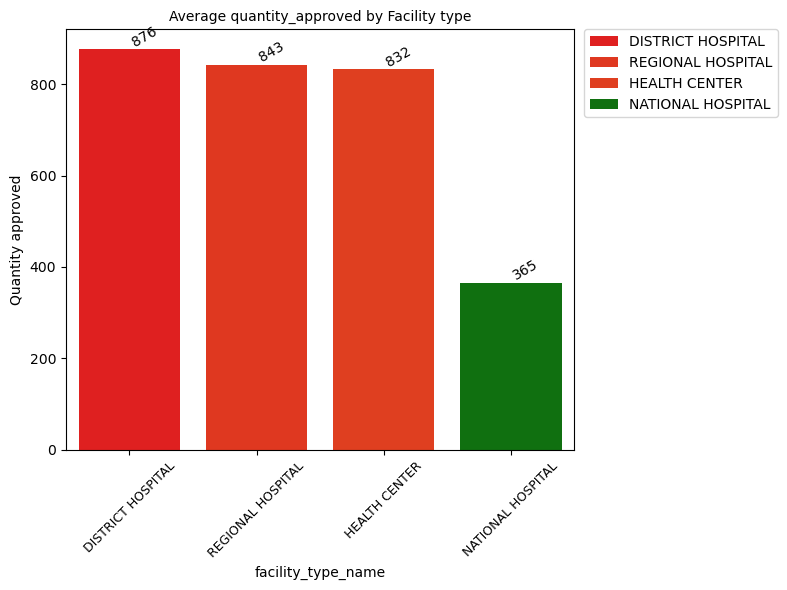

In [39]:
plt.figure(figsize=(8,6))
# Create bar plot of total quantities approved per products
qty_by_facility_type= (
    #categorical_predictors[categorical_predictors['product_primary_name'].isin(['ACT-INF', 'ACT-SC', 'ACT-GC', 'ACT-AD'])].groupby('product_primary_name')['quantity_approved']
    categorical_predictors.groupby('facility_type_name')['quantity_approved']
      .mean()
      .sort_values(ascending=False)
)
#qty_by_product=qty_by_product.reindex(index=product_order)
# Normalisation des valeurs
norm = colors.Normalize(
    vmin=qty_by_facility_type.min(),
    vmax=qty_by_facility_type.max()
)
# Assigning a color to each bar
bar_colors = [cmap(norm(value)) for value in qty_by_facility_type.values]
ax=sns.barplot(x=qty_by_facility_type.index, y=qty_by_facility_type.values,palette=bar_colors, hue=qty_by_facility_type.index,
                 legend=True )
#ax.set_xticklabels(product_order)
# Add labels on bars
for container in ax.containers:
    labels=ax.bar_label(container, fmt='{:,.0f}')
    for label in labels:
        label.set_rotation(30)
        label.set_horizontalalignment('left')
        label.set_verticalalignment('bottom')
ax.set_ylabel('Quantity approved')
ax.tick_params(axis='x', labelrotation=45, labelsize=9)
ax.set_title('Average quantity_approved by Facility type', fontsize=10);
#plt.xticks(rotation=45, ha='right')
ax.legend(title='',loc="upper left",
    bbox_to_anchor=(1.02, 1),   # Outside the plot on the right
    borderaxespad=0)
plt.tight_layout()
plt.show()

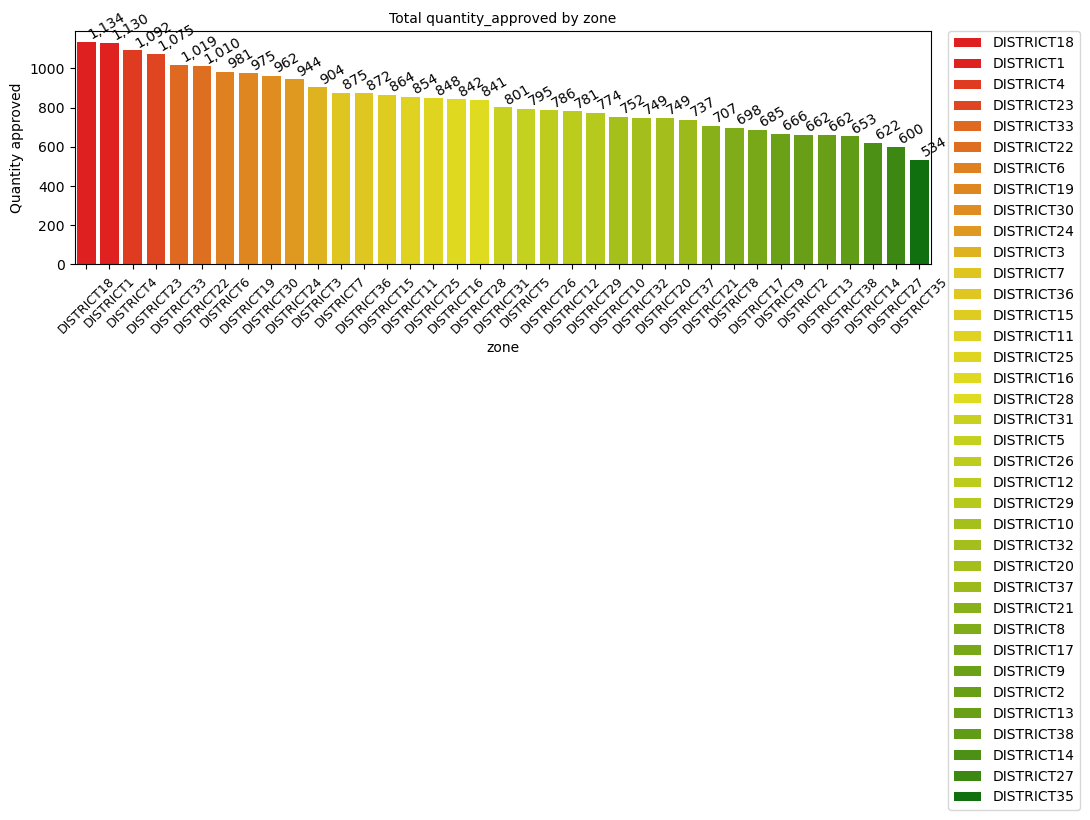

In [40]:
plt.figure(figsize=(11,6))
# Create bar plot of total quantities approved per products
qty_by_zone= (
    #categorical_predictors[categorical_predictors['product_primary_name'].isin(['ACT-INF', 'ACT-SC', 'ACT-GC', 'ACT-AD'])].groupby('product_primary_name')['quantity_approved']
    categorical_predictors.groupby('zone')['quantity_approved']
      .mean()
      .sort_values(ascending=False)
)
#qty_by_product=qty_by_product.reindex(index=product_order)
# Normalisation des valeurs
norm = colors.Normalize(
    vmin=qty_by_zone.min(),
    vmax=qty_by_zone.max()
)
# Assigning a color to each bar
bar_colors = [cmap(norm(value)) for value in qty_by_zone.values]
ax=sns.barplot(x=qty_by_zone.index, y=qty_by_zone.values,palette=bar_colors, hue=qty_by_zone.index,
                 legend=True )
#ax.set_xticklabels(product_order)
# Add labels on bars
for container in ax.containers:
    labels=ax.bar_label(container, fmt='{:,.0f}')
    for label in labels:
        label.set_rotation(30)
        label.set_horizontalalignment('left')
        label.set_verticalalignment('bottom')
ax.set_ylabel('Quantity approved')
ax.tick_params(axis='x', labelrotation=45, labelsize=9)
ax.set_title('Total quantity_approved by zone', fontsize=10);
#plt.xticks(rotation=45, ha='right')
ax.legend(title='',loc="upper left",
    bbox_to_anchor=(1.02, 1),   # Outside the plot on the right
    borderaxespad=0)
plt.tight_layout()
plt.show()

The graphical analysis confirms the descriptive statistics by showing that the categorical predictors exhibit meaningful but moderate differences in average approved quantities. **Products and reporting month** will be retained because they capture product-specific and seasonal variation in approval decisions. **Facility type** will be simplified into Health Center and Hospital, while **zone** will be transformed into an Urban/Rural indicator to reduce dimensionality and improve model interpretability. These feature engineering decisions are expected to produce more robust Multiple Linear Regression, Decision Tree, and Random Forest models without sacrificing the operational relevance of the predictors.

## 3.Relationship Between Predictors and target

Create a pairplot to visualize the relationship between the continous variables in `data`.

In [41]:
data_countinuous_var=df[["quantity_received",'quantity_dispensed','stock_in_hand',
                        'quantity_requested','total_losses_and_adjustments','amc','quantity_approved']]

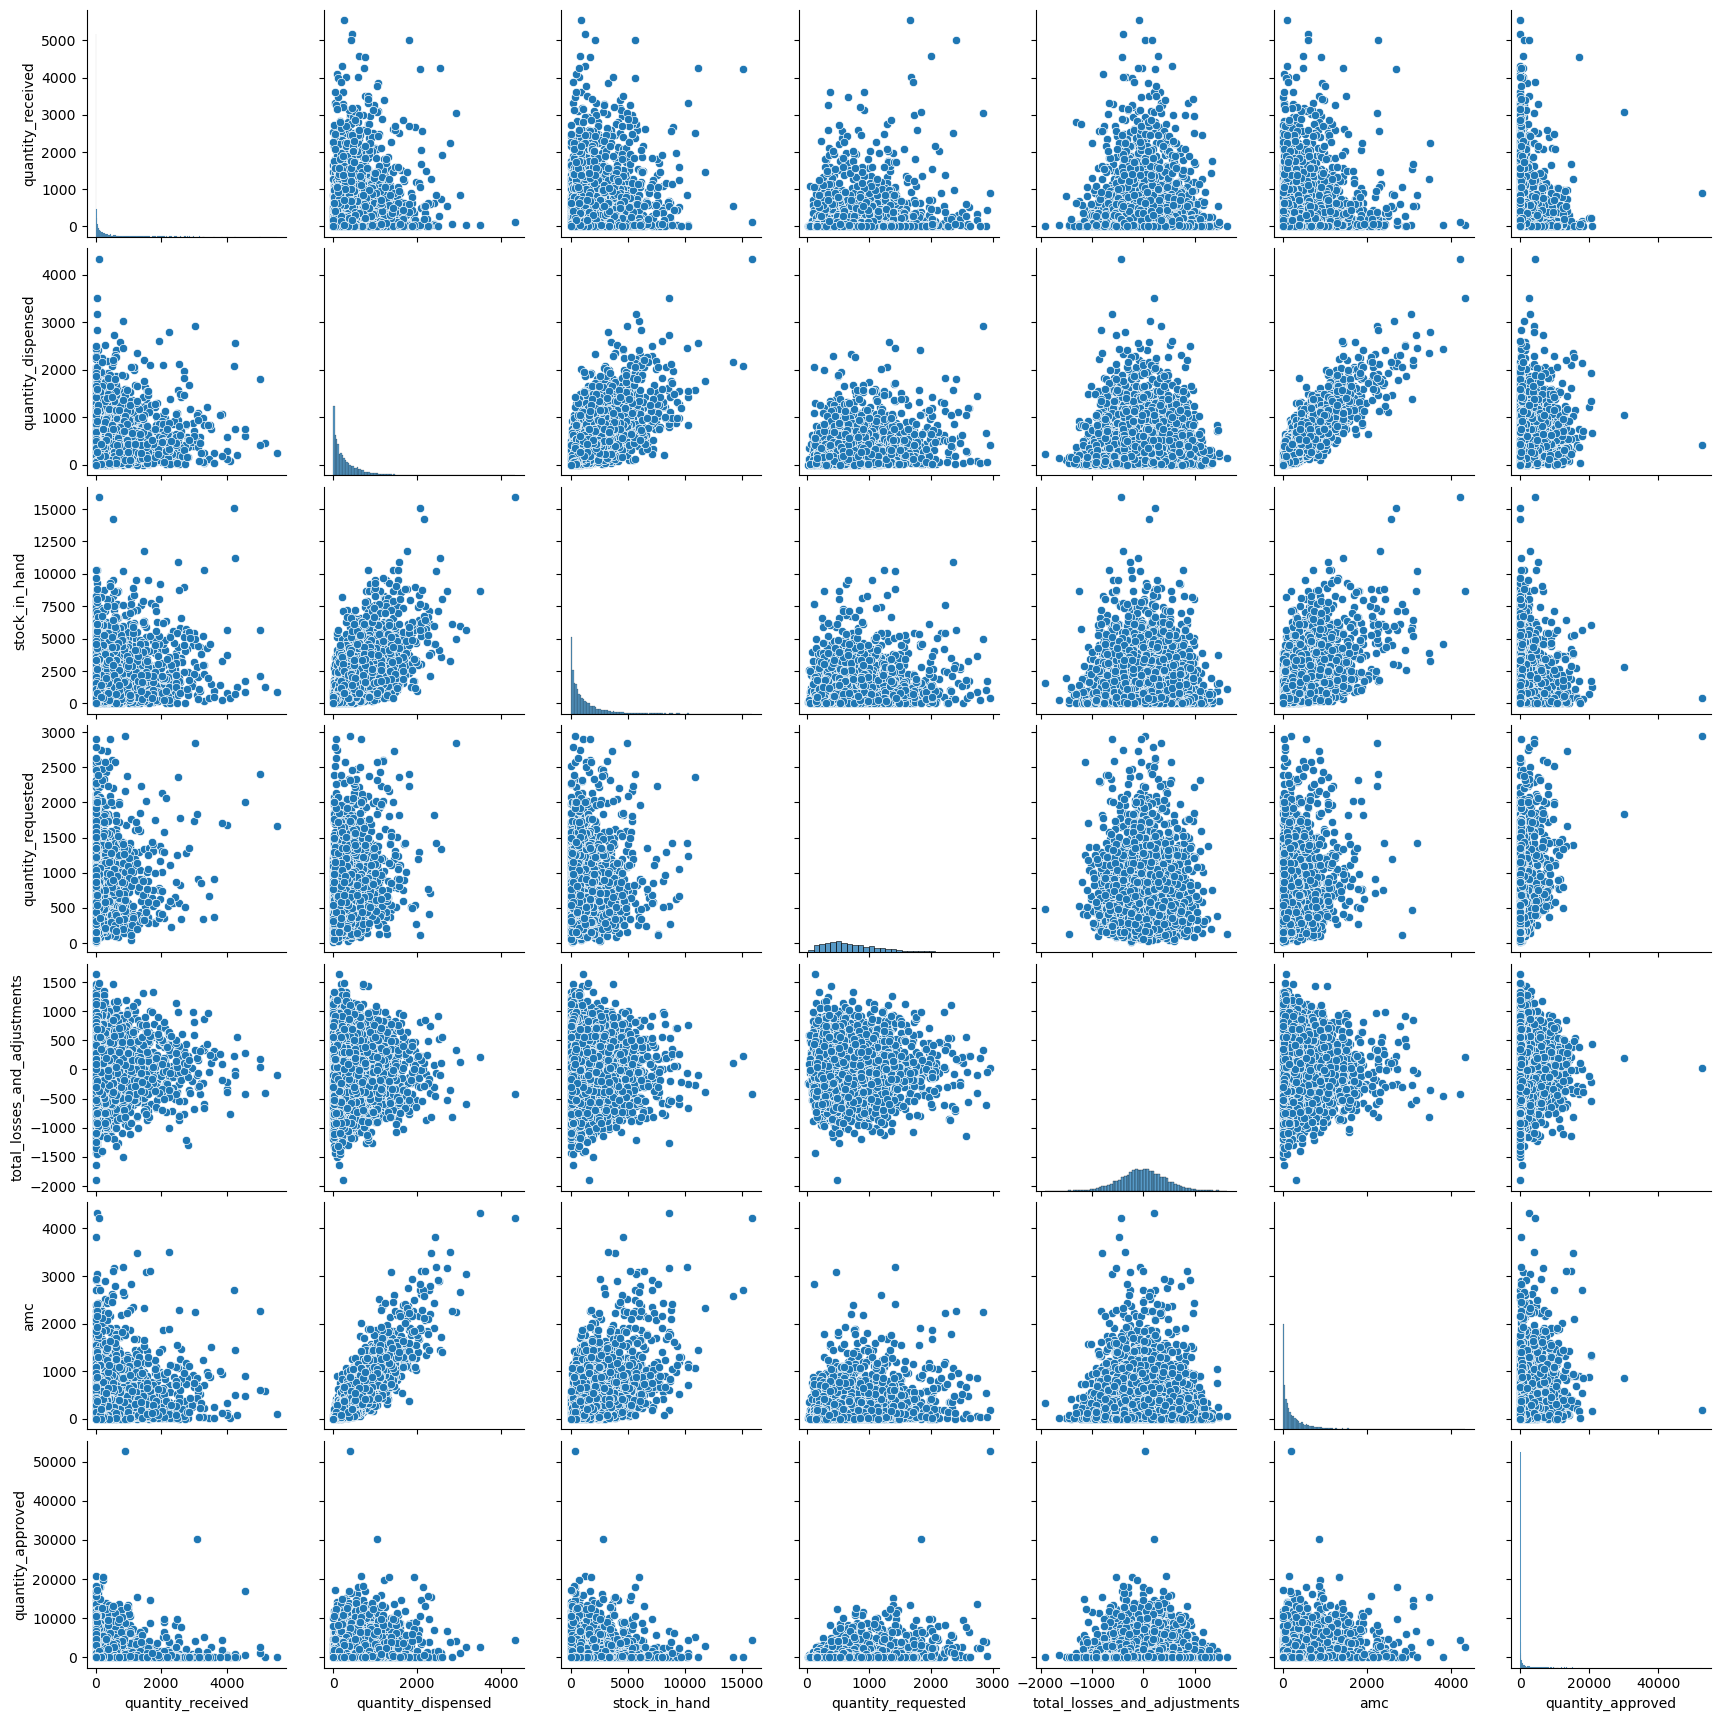

In [42]:
sns.pairplot(data_countinuous_var)

* The pairplot suggests that the relationships between the numerical predictors and the approved quantity are predominantly non-linear and influenced by substantial variability and extreme observations.
* Among the predictors, Average Monthly Consumption (AMC) and Quantity Dispensed appear to show the strongest positive association
* Similarly, Stock in Hand and Quantity Received exhibit weak or irregular relationships with the approved quantity, indicating that approval decisions are unlikely to be explained by a single inventory variable alone.
* The pairplot also suggests the presence of relationships among some predictor variables. In particular, AMC appears to be strongly associated with Quantity Dispensed, and Stock in Hand shows a positive association with Quantity dispensed. These relationships indicate the potential presence of multicollinearity, which could be formally assessed using correlation analysis and the Variance Inflation Factor (VIF) before fitting the regression model.
*  Nevertheless, the pairplot alone is insufficient to reject Multiple Linear Regression, as it only illustrates pairwise relationships and does not account for the combined effects of multiple predictors. Consequently, Multiple Linear Regression will be developed as a baseline predictive model, followed by comprehensive regression diagnostics and a comparison with Decision Tree and Random Forest models to identify the approach that provides the best predictive performance.

## 4.Feature Engineering

### 4.1. Feature Selection
At this stage we are going to select the variables that contribute to predicting the approved quantity while removing redundant or non-informative variables.

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   product_primary_name          8763 non-null   object 
 1   processing_periods_name       8763 non-null   object 
 2   facility_type_name            8763 non-null   object 
 3   beginning_balance             8763 non-null   float64
 4   quantity_received             8763 non-null   float64
 5   quantity_dispensed            8763 non-null   float64
 6   stock_in_hand                 8763 non-null   float64
 7   quantity_requested            2420 non-null   float64
 8   quantity_approved             8763 non-null   float64
 9   total_losses_and_adjustments  8763 non-null   int64  
 10  amc                           8763 non-null   float64
 11  pack_size                     8763 non-null   int64  
 12  zone                          8763 non-null   object 
 13  dis

Based on the previous analysis, the following predictors are retained:
* beginning_balance
* quantity_received
* quantity_dispensed
* stock_in_hand
* total_losses_and_adjustments
* amc
* product_primary_name
* facility_type_name
* processing_periods_name
* zone

### 4.2. Feature transformation

At this stage, we prepare variables for Model learning

#### reporting_month

Rather than using the complete reporting period (year-month-day) as a categorical predictor, the reporting month (February, May, August, and November) will be extracted and used as the temporal feature. 

In [44]:
df['processing_periods_name'].dtype

dtype('O')

In [45]:
df["processing_periods_name"] = pd.to_datetime(df["processing_periods_name"])

In [46]:
df['processing_periods_name'].dtype

dtype('<M8[ns]')

In [47]:
df["reporting_month"] = df["processing_periods_name"].dt.month_name()

In [73]:
df["reporting_month"].unique()

array(['May', 'February', 'August', 'November'], dtype=object)

#### facility_type

National Hospitals will be grouped with Regional and District Hospitals under a single Hospital category, while Health Centers will be retained as separate categories.

In [49]:
df['facility_type_name'].unique()

array(['HEALTH CENTER', 'DISTRICT HOSPITAL', 'REGIONAL HOSPITAL',
       'NATIONAL HOSPITAL'], dtype=object)

In [50]:
type_facility_dict = {
    'DISTRICT HOSPITAL': 'HOSPITAL',
    'REGIONAL HOSPITAL': 'HOSPITAL',
    'NATIONAL HOSPITAL': 'HOSPITAL',
    'HEALTH CENTER':'HEALTH CENTER'
}
df['facility_type'] = df['facility_type_name'].map(type_facility_dict)

In [51]:
df['facility_type'].unique()

array(['HEALTH CENTER', 'HOSPITAL'], dtype=object)

#### zone_type 

Because the variable contains 37 categories, directly applying one-hot encoding would substantially increase the number of model parameters while providing limited interpretability. Consequently, the zone variable will be transformed into a higher-level geographical feature which is the zone_type: Urban and Rural before modeling.
Based on data provided at operational level we will transform the zone as defined below


In [52]:
type_district_dict = {
    'DISTRICT1': 'RURAL',
    'DISTRICT2': 'RURAL',
    'DISTRICT3': 'URBAN',
    'DISTRICT4': 'RURAL',
    'DISTRICT5': 'RURAL',
    'DISTRICT6': 'RURAL',
    'DISTRICT7': 'URBAN',
    'DISTRICT8': 'RURAL',
    'DISTRICT9': 'RURAL',
    'DISTRICT10': 'RURAL',
    'DISTRICT11': 'RURAL',
    'DISTRICT12': 'RURAL',
    'DISTRICT13': 'RURAL',
    'DISTRICT14': 'RURAL',
    'DISTRICT15': 'URBAN',
    'DISTRICT16': 'RURAL',
    'DISTRICT17': 'RURAL',
    'DISTRICT18': 'RURAL',
    'DISTRICT19': 'RURAL',
    'DISTRICT20': 'URBAN',
    'DISTRICT21': 'RURAL',
    'DISTRICT22': 'RURAL',
    'DISTRICT23': 'RURAL',
    'DISTRICT24': 'RURAL',
    'DISTRICT25': 'URBAN',
    'DISTRICT26': 'RURAL',
    'DISTRICT27': 'URBAN',
    'DISTRICT28': 'URBAN',
    'DISTRICT29': 'URBAN',
    'DISTRICT30': 'RURAL',
    'DISTRICT31': 'URBAN',
    'DISTRICT32': 'RURAL',
    'DISTRICT33': 'RURAL',
    'DISTRICT34': 'RURAL',
    'DISTRICT35': 'RURAL',
    'DISTRICT36': 'RURAL',
    'DISTRICT37': 'URBAN',
    'DISTRICT38': 'RURAL'
}
df['zone_type'] = df['zone'].map(type_district_dict)
df['zone_type'].unique()

array(['URBAN', 'RURAL'], dtype=object)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   product_primary_name          8763 non-null   object        
 1   processing_periods_name       8763 non-null   datetime64[ns]
 2   facility_type_name            8763 non-null   object        
 3   beginning_balance             8763 non-null   float64       
 4   quantity_received             8763 non-null   float64       
 5   quantity_dispensed            8763 non-null   float64       
 6   stock_in_hand                 8763 non-null   float64       
 7   quantity_requested            2420 non-null   float64       
 8   quantity_approved             8763 non-null   float64       
 9   total_losses_and_adjustments  8763 non-null   int64         
 10  amc                           8763 non-null   float64       
 11  pack_size                     

### 4.3. Feature Extraction

At this stage, we derive variables with stronger operational meaning for our models to improve interpretability

#### High_Transmission_Preparation period

Malaria commodity requirements may vary according to seasonal changes in malaria transmission (Case of Most West African Countries). Within the supply chain ordering cycle, May and August are considered preparation periods because they precede periods of higher malaria transmission, during which increased consumption of malaria commodities may be expected.

To capture this operational seasonality in the predictive models, a new binary feature, **High_Transmission_Preparation**, will be derived from the reporting month. The variable will take the value "YES" for orders placed in May and August and "NO" for normal ordering periods.

In [54]:
reporting_month_transmission_dict = {
    'February': 'NO',
    'May': 'YES',
    'August': 'YES',
    'November':'NO'
}
df['High_Transmission_Preparation'] = df['reporting_month'].map(reporting_month_transmission_dict)
df['High_Transmission_Preparation'].unique()

array(['YES', 'NO'], dtype=object)

In [55]:
df[['High_Transmission_Preparation','reporting_month']].drop_duplicates()

,High_Transmission_Preparation,reporting_month
0,YES,May
2,NO,February
3,YES,August
6,NO,November


#### Products group

To reduce product-level granularity while preserving characteristics that may influence commodity consumption and allocation patterns, the 12 malaria commodities were classified into six groups based on their clinical function, dispensing-unit characteristics, pack size, and relevant operational considerations.
* ACT-INF, ACT-SC, ACT-GC, and ACT-AD: grouped as ACT, as they are used for uncomplicated malaria treatment and share similar logistics characteristics (Dispensing unit and packsize).
* PYRA-COMP and PYRA-SAC: grouped as PYRA because they are used for uncomplicated malaria treatment and have the same pack size, despite differences in dispensing units
* ART-INJ and ART-SUP were grouped as ART, reflecting their role in severe-malaria treatment and similar logistic characteristics (dispensing unit)
* QUIN and SP were grouped as SP primarily because they share the same dispensing unit and pack size, although they have different clinical indications. Their grouping also reflects the operational context in which their roles in malaria case management are evolving as they are planned to be replaced in near feature by ACT ( programmatic claims, in real case this should be supported by the applicable national malaria treatment guidelines or another authoritative source)
* ITN and RDT were retained as separate groups because they serve fundamentally different programmatic functions: ITNs are used for malaria prevention and constitute the PREV group, while RDTs are used for malaria diagnosis and constitute the DIAG group.

In [56]:
product_group_dict = {
    'ACT-INF': 'ACT',
    'ACT-SC': 'ACT',
    'ACT-GC': 'ACT',
    'ACT-AD':'ACT',
    'PYRA-COMP':'PYRA',
    'PYRA-SAC':'PYRA',
    'ART-INJ':'ART',
    'ART-SUP':'ART',
    'QUIN':'SP',
    'SP':'SP',
    'ITN':'PREV',
    'RDT':'DIAG' 
}
df['product_group'] = df['product_primary_name'].map(product_group_dict)
df['product_group'].unique()

array(['PYRA', 'ACT', 'ART', 'DIAG', 'PREV', 'SP'], dtype=object)

In [57]:
# Display observation with NaN in the product_group
#df[pd.isnull(df['product_group'])].head()

#### Months of Stock

The Months of Stock (MoS) feature represents the number of months that the current inventory could theoretically support. It is calculated as:

**mos=stock_in_hand/amc**

This feature is particularly relevant for predicting quantity_approved because supply chain allocation decisions are generally based not only on absolute stock quantities but also on stock adequacy relative to consumption.

In [67]:
df["months_of_stock"] = np.divide(
    df["stock_in_hand"],
    df["amc"],
    out=np.full(len(df), np.nan, dtype=float),
    where=df["amc"].ne(0)
).round(1)
df["months_of_stock"].head()

0    9.4
1    3.2
2    4.5
3    NaN
4    3.7
Name: months_of_stock, dtype: float64

In [68]:
print("AMC = 0:", (df["amc"] == 0).sum())
print("Missing MoS:", df["months_of_stock"].isna().sum())
print(
    "Infinite MoS:",
    np.isinf(df["months_of_stock"]).sum()
)

AMC = 0: 282
Missing MoS: 282
Infinite MoS: 0


In our operational context, AMC = 0 can represent at least two situations:
* Very low or no recent consumption — the product was not or barely dispensed during the AMC calculation window.
* Prolonged stock-out — the facility could not dispense the product because it was unavailable.

#### Stock status

The stock_status feature transforms the continuous months_of_stock variable into operational inventory categories. Based on the supply chain thresholds used in this study, observations are classified as Stockout, Critical, Low, Adequate, or Overstock.
The boundaries are defined as:
* MoS = 0: Stockout
* 0 < MoS ≤ 1: Critical
* 1 < MoS < 3: Low
* 3 ≤ MoS ≤ 5: Adequate
* MoS > 5: Overstock
* MoS undefined (NaN): Unknown

In [69]:
conditions = [
    df["months_of_stock"].eq(0),
    df["months_of_stock"].gt(0) & df["months_of_stock"].le(1),
    df["months_of_stock"].gt(1) & df["months_of_stock"].lt(3),
    df["months_of_stock"].ge(3) & df["months_of_stock"].le(5),
    df["months_of_stock"].gt(5)
]

choices = [
    "Stockout",
    "Critical",
    "Low",
    "Adequate",
    "Overstock"
]

df["stock_status"] = np.select(
    conditions,
    choices,
    default="Unknown"
)

In [70]:
df["stock_status"].value_counts()

stock_status
Overstock    4365
Low          1785
Adequate     1428
Critical      892
Unknown       282
Stockout       11
Name: count, dtype: int64

## Final dataset for model construction

In [74]:
# Save the data for model construction
retained_features = ['product_primary_name','product_group','facility_type','reporting_month','High_Transmission_Preparation','zone_type',
                     'beginning_balance','quantity_received','quantity_dispensed','total_losses_and_adjustments','stock_in_hand','months_of_stock',
                     'stock_status','amc','quantity_approved']
df_model_construction = df[retained_features].copy()
df_model_construction.rename(columns={'product_primary_name':'product'},inplace=True)
df_model_construction.head(5)

,product,product_group,facility_type,reporting_month,High_Transmission_Preparation,zone_type,beginning_balance,quantity_received,quantity_dispensed,total_losses_and_adjustments,stock_in_hand,months_of_stock,stock_status,amc,quantity_approved
0,PYRA-COMP,PYRA,HEALTH CENTER,May,YES,URBAN,3510.0,6.0,437.0,246,1426.0,9.4,Overstock,151.0,0.0
1,ACT-GC,ACT,HEALTH CENTER,May,YES,URBAN,89.0,1.0,57.0,209,65.0,3.2,Adequate,20.0,620.0
2,ACT-AD,ACT,HEALTH CENTER,February,NO,RURAL,4125.0,2604.0,1423.0,-179,6554.0,4.5,Adequate,1464.0,13.0
3,ART-SUP,ART,HEALTH CENTER,August,YES,RURAL,20.0,0.0,2.0,-456,185.0,NaN,Unknown,0.0,0.0
4,RDT,DIAG,HEALTH CENTER,February,NO,URBAN,2243.0,0.0,535.0,420,2167.0,3.7,Adequate,583.0,319.0


In [75]:
df_model_construction.to_csv("../data/dataset_model.csv",index=False)